# Exploratory Data Analysis & Introduction

Objects

1. Retrieve top-paying roles and skills in the data industry.
2. Use Python to explore a Luke Barousse's dataset on job postings.
3. For job-seekers: uses these insights to help find the best job opportunities.

### Final Deliverables:

* Create Jupyter Notebookss (showcasing core skills in Python).
* Create a summary page (via README.md) capturing your findings.
* Share this project via GitHub & LinkedIn.

### Questions to Answer

1. What are the most demanded skills for the top 5 most popular data roles?
2. How are in-demand skills trending for the top 5 most popular data roles?
3. What is the most optimal skill to learn for the top 5 most popular data roles? (High Demand AND High Paying)

### Exploratory Data Analysis for all Data Roles

#### Roles to Explore

In [3]:
#Turn off warning notification
import warnings
warnings.filterwarnings("ignore")

import datasets
datasets.logging.set_verbosity_error()

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from datasets import load_dataset

# Loading dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

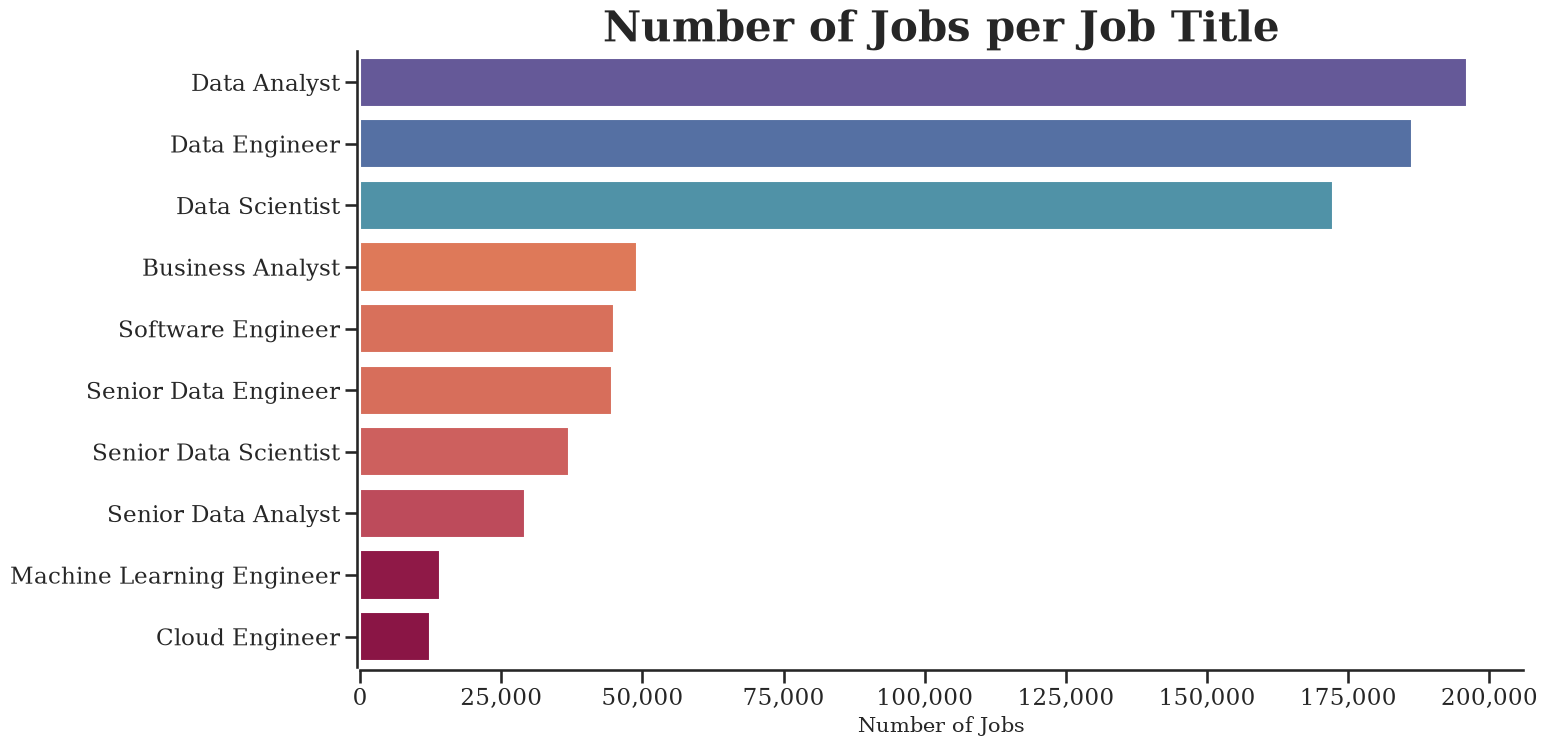

In [135]:
df_job_count = pd.DataFrame(df['job_title_short'].value_counts())

fig, ax = plt.subplots(figsize = (15, 8))

sns.set_theme(
                style='ticks'
                , palette = 'Spectral'
                , context="talk"
                , font = 'serif'
                , font_scale = 1)

sns.barplot(
            data = df_job_count
            , x = 'count'
            , y = 'job_title_short'
            , hue = 'count'
            , palette = 'Spectral'
            , legend = False)

sns.despine(offset=2)

plt.title(
            'Number of Jobs per Job Title'
            , fontdict={'fontsize': 30, 'fontweight': 'bold'}
            , loc = 'center')

plt.xlabel(
            'Number of Jobs'
            , fontdict={'fontsize': 15})

plt.ylabel('')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.show()



### Countries to Explore

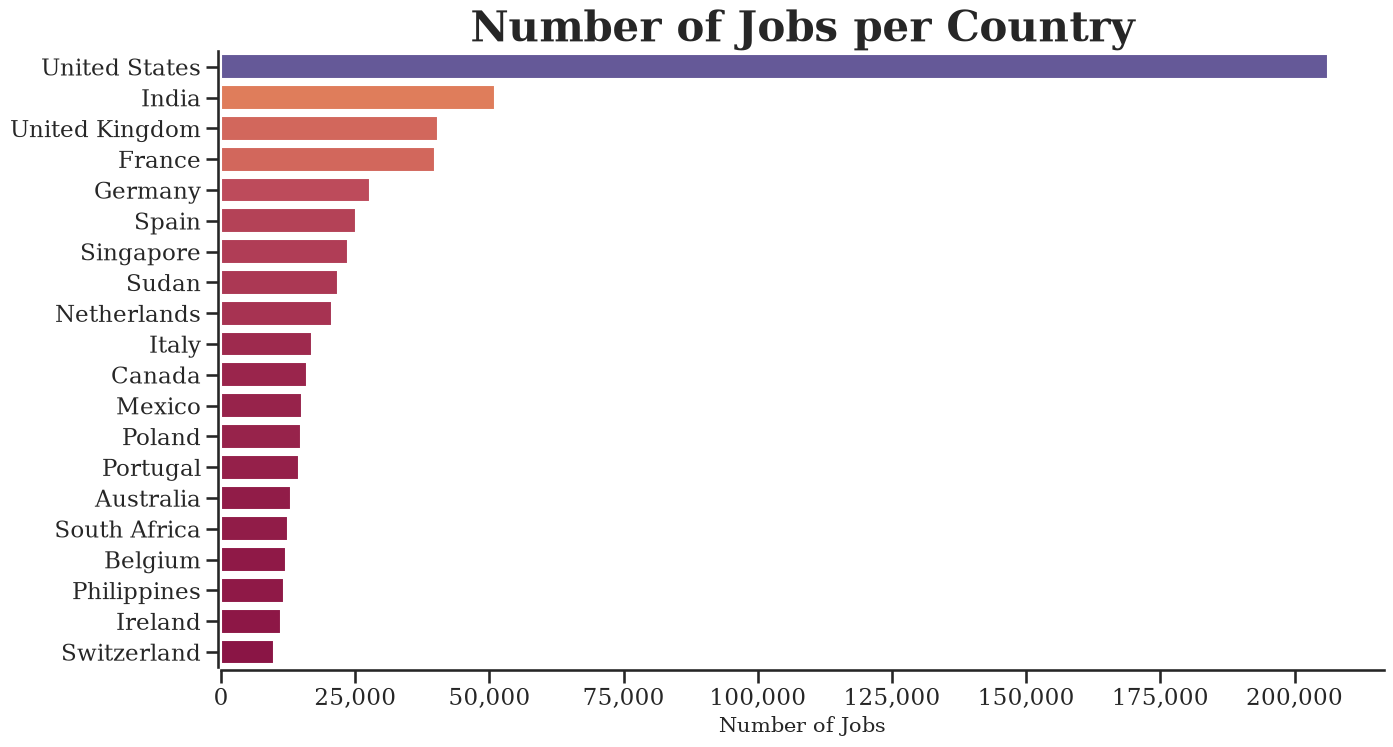

In [134]:
df_top20_countries = df['job_country'].value_counts().to_frame().head(20)

fig, ax = plt.subplots(figsize = (15, 8))

sns.set_theme(
                style='ticks'
                , palette = 'Spectral'
                , context="talk"
                , font = 'serif'
                , font_scale = 1)

sns.barplot(
            data = df_top20_countries
            , x = 'count'
            , y = 'job_country'
            , hue = 'count'
            , palette = 'Spectral'
            , legend = False)

sns.despine(offset=2)

plt.title(
            'Number of Jobs per Country'
            , fontdict={'fontsize': 30, 'fontweight': 'bold'}
            , loc = 'center')

plt.xlabel(
            'Number of Jobs'
            , fontdict={'fontsize': 15})

plt.ylabel('')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.show()

### Companies to Explore

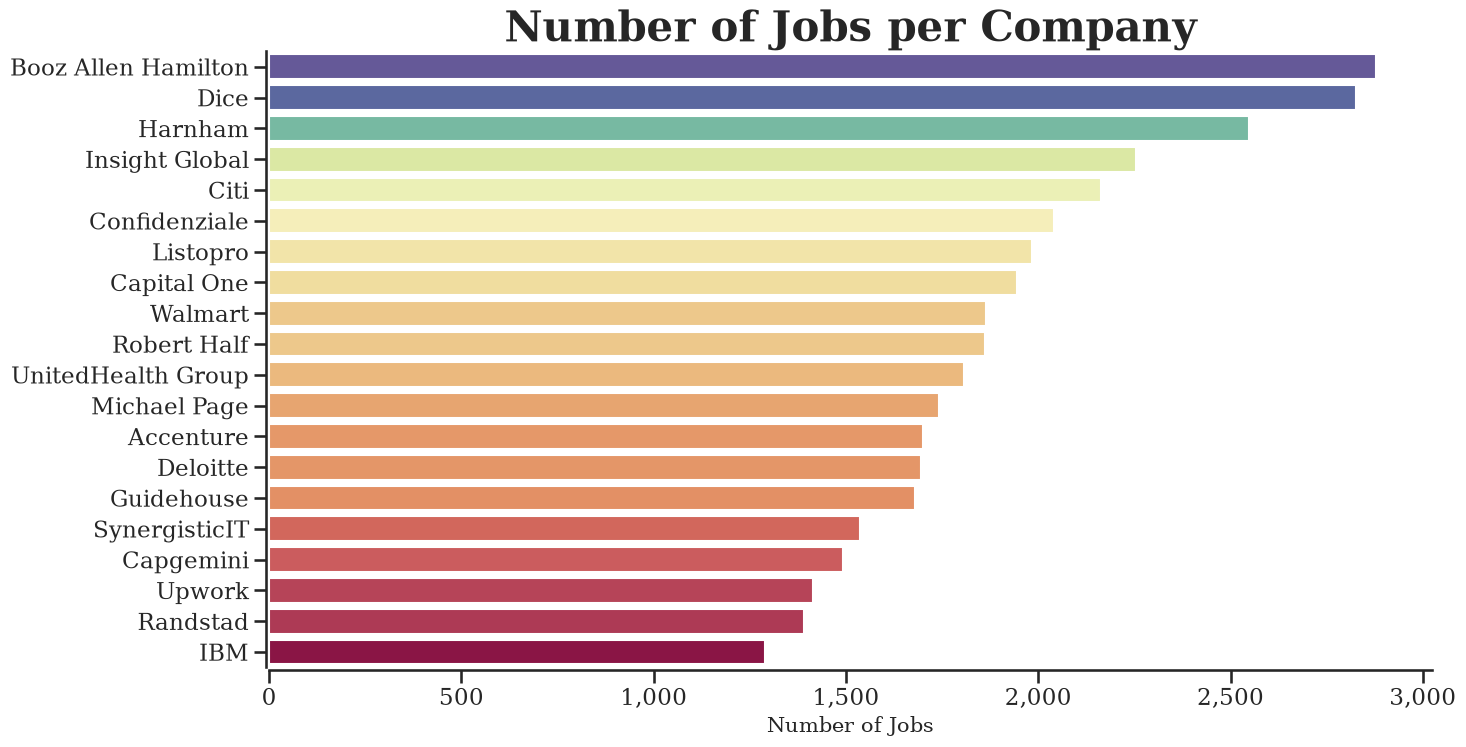

In [136]:
df_top20_companies = df['company_name'].value_counts().to_frame()[1:].head(20)

fig, ax = plt.subplots(figsize = (15, 8))

sns.set_theme(
                style='ticks'
                , palette = 'Spectral'
                , context="talk"
                , font = 'serif'
                , font_scale = 1)

sns.barplot(
            data = df_top20_companies
            , x = 'count'
            , y = 'company_name'
            , hue = 'count'
            , palette = 'Spectral'
            , legend = False)

sns.despine(offset=2)

plt.title(
            'Number of Jobs per Company'
            , fontdict={'fontsize': 30, 'fontweight': 'bold'}
            , loc = 'center')

plt.xlabel(
            'Number of Jobs'
            , fontdict={'fontsize': 15})

plt.ylabel('')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.show()

### Job Scheduled Type - Degree Mention - Health Insurance

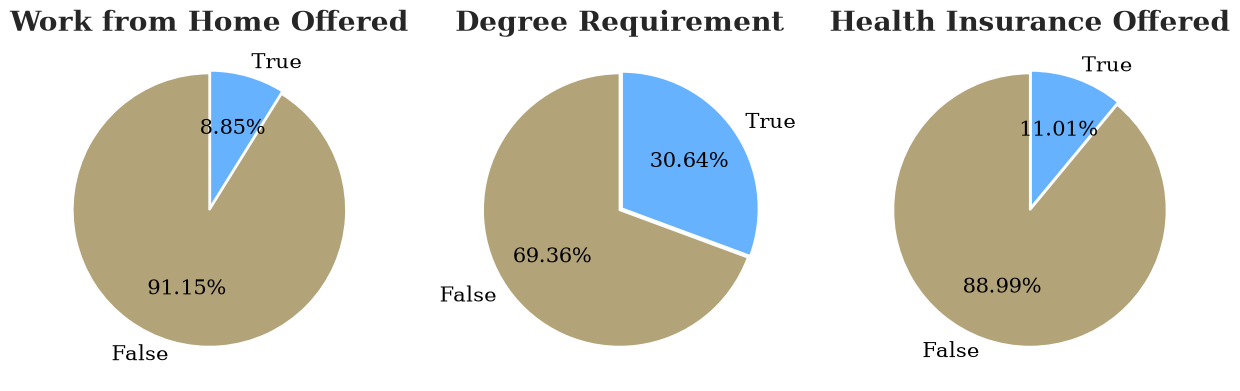

In [156]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, len(dict_column.keys()), figsize=(15, 8))

for index, (column, title) in enumerate(dict_column.items()):
    ax[index].pie(
                    df[column].value_counts()
                    , labels = ['False','True']
                    , autopct = "%1.2f%%"
                    , startangle = 90
                    , explode=(0, 0.02)
                    , textprops={'fontsize': 15, 'color': 'black'}
                    , colors = ["#B3A378", "#66B2FF"])

    ax[index].set_title(
                        title
                        , fontsize = 20
                        , fontweight = 'bold')

plt.show()

### Filter for Southeast Asia Data Analyst, Engineer and Scientist roles

In [95]:
countries = ['Brunei', 'Cambodia', 'Indonesia', 'Laos', 'Malaysia' , 'Myanmar'
             , 'Philippines', 'Singapore', 'Thailand', 'East Timor', 'Vietnam']

job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

In [96]:
df_SEA = df[(df['job_country'].isin(countries)) & (df['job_title_short'].isin(job_titles))]

### Locations to Explore:

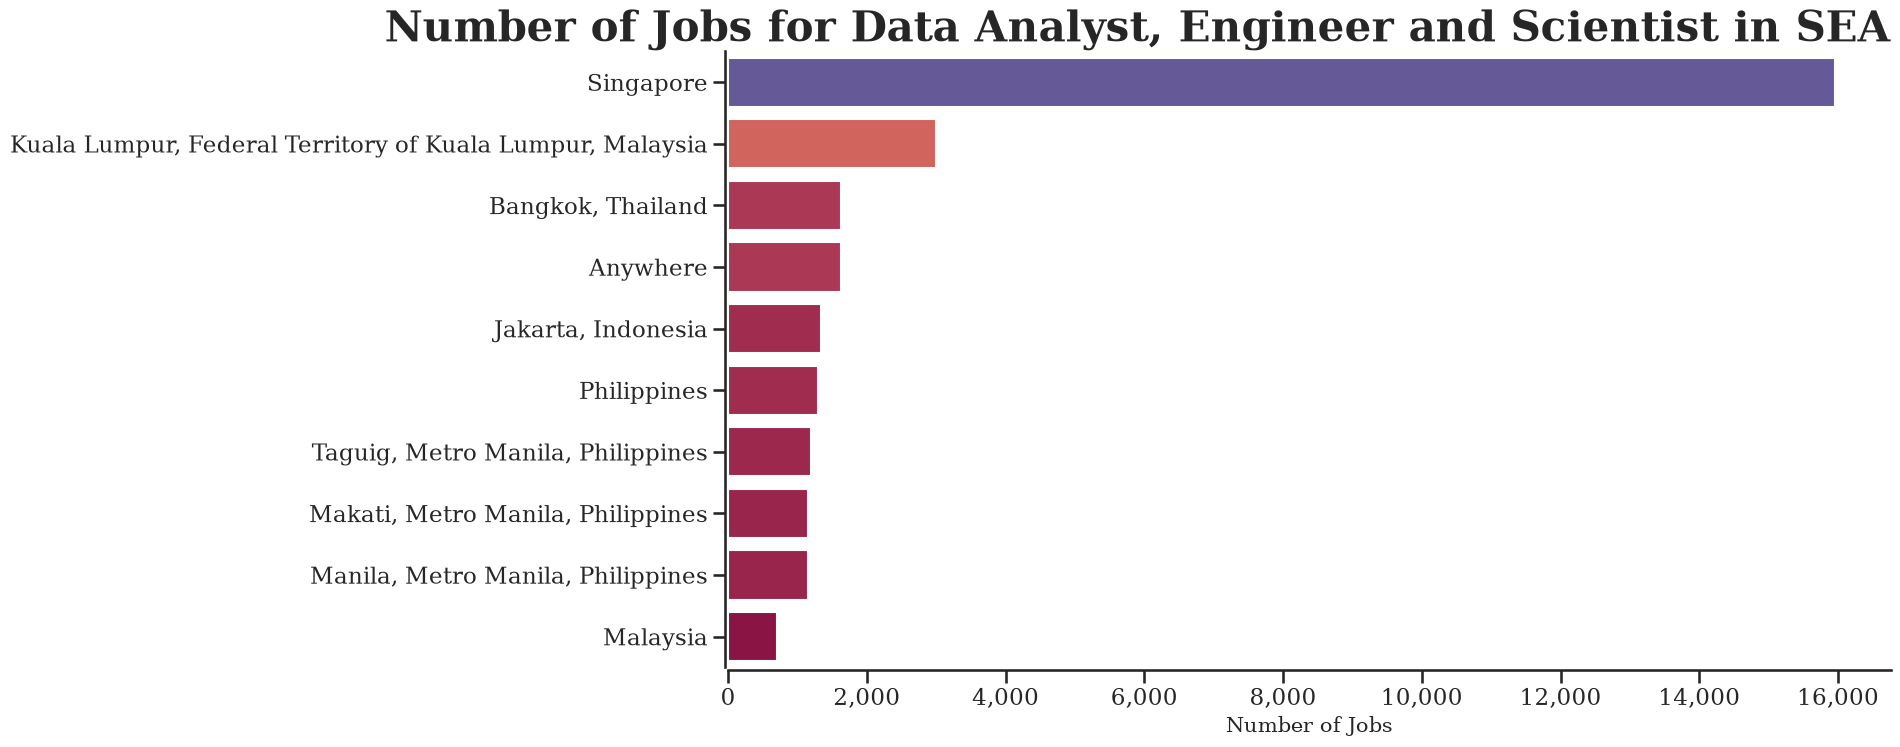

In [125]:
df_location = df_SEA['job_location'].value_counts().head(10).to_frame()

fig, ax = plt.subplots(figsize = (15, 8))

sns.set_theme(
                style='ticks'
                , palette = 'Spectral'
                , context="talk"
                , font = 'serif'
                , font_scale = 1)

sns.barplot(
            data = df_location
            , x = 'count'
            , y = 'job_location'
            , hue = 'count'
            , palette = 'Spectral'
            , legend = False)

sns.despine(offset=2)

plt.title(
            'Number of Jobs for Data Analyst, Engineer and Scientist in SEA'
            , fontdict={'fontsize': 30, 'fontweight': 'bold'}
            , loc = 'right')

plt.xlabel(
            'Number of Jobs'
            , fontdict={'fontsize': 15})

plt.ylabel('')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.show()

### Job Scheduled Type - Degree Mention - Health Insurance in SEA